<a href="https://colab.research.google.com/github/akshaykrishnas2200-cpu/Machine-learning/blob/main/exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
classification_report,
accuracy_score,
confusion_matrix
)

In [3]:
import seaborn as sns

In [5]:
# Load Fashion-MNIST dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = \
fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Class names
class_names = [
'T-shirt/top',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

In [7]:
print(f"Full Training set shape: {X_train_full.shape}")
print(f"Full Test set shape: {X_test_full.shape}")

Full Training set shape: (60000, 28, 28)
Full Test set shape: (10000, 28, 28)


In [8]:
# Stratified subsampling
_, X_train_sub, _, y_train_sub = train_test_split(
X_train_full,
y_train_full,
test_size=10000,
stratify=y_train_full,
random_state=42
)
_, X_test_sub, _, y_test_sub = train_test_split(
X_test_full,
y_test_full,
test_size=2000,
stratify=y_test_full,
random_state=42
)

In [9]:
# Flatten images
X_train_flat = X_train_sub.reshape(
X_train_sub.shape[0], -1
)
X_test_flat = X_test_sub.reshape(
X_test_sub.shape[0], -1
)

In [10]:
# Normalize pixel values
X_train_norm = X_train_flat / 255.0
X_test_norm = X_test_flat / 255.0

In [11]:
print(
f"\nSubsampled & Processed Training Shape: "
f"{X_train_norm.shape}"
)
print(
f"Subsampled & Processed Testing Shape: "
f"{X_test_norm.shape}"
)


Subsampled & Processed Training Shape: (10000, 784)
Subsampled & Processed Testing Shape: (2000, 784)


In [12]:
# Test different K values
k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = []
inference_times = []

In [14]:
print("Starting KNN Experiments...\n")
for k in k_values:
    print(f"Evaluating K = {k}...")
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2,
        n_jobs=-1
    )

Starting KNN Experiments...

Evaluating K = 1...
Evaluating K = 3...
Evaluating K = 5...
Evaluating K = 7...
Evaluating K = 9...
Evaluating K = 11...
Evaluating K = 15...


In [15]:
knn.fit(X_train_norm, y_train_sub)

KNeighborsClassifier(n_jobs=-1, n_neighbors=15)

In [16]:
# Measure prediction time
start_time = time.time()
y_pred = knn.predict(X_test_norm)
end_time = time.time()
elapsed_time = end_time - start_time
acc = accuracy_score(y_test_sub, y_pred)
accuracies.append(acc)
inference_times.append(elapsed_time)

In [17]:
print(
f"-> Accuracy: {acc:.4f} | "
f"Inference Time: {elapsed_time:.2f} seconds\n"
)


-> Accuracy: 0.8040 | Inference Time: 2.89 seconds



In [18]:
# Find best K
best_k_idx = np.argmax(accuracies)
best_k = k_values[best_k_idx]
print(f"Optimal configuration found at K = {best_k}")
# Train best KNN model
best_knn = KNeighborsClassifier(
n_neighbors=best_k,
n_jobs=-1
)

Optimal configuration found at K = 1


In [19]:
best_knn.fit(X_train_norm, y_train_sub)
y_pred_best = best_knn.predict(X_test_norm)

In [20]:
# Classification report
print("\n### Classification Report ###")
print(
classification_report(
y_test_sub,
y_pred_best,
target_names=class_names
)
)


### Classification Report ###
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.78      0.77       200
     Trouser       0.98      0.97      0.98       200
    Pullover       0.63      0.76      0.69       200
       Dress       0.87      0.81      0.84       200
        Coat       0.68      0.64      0.66       200
      Sandal       1.00      0.76      0.86       200
       Shirt       0.51      0.51      0.51       200
     Sneaker       0.85      0.94      0.89       200
         Bag       0.97      0.93      0.95       200
  Ankle boot       0.84      0.94      0.89       200

    accuracy                           0.80      2000
   macro avg       0.81      0.80      0.80      2000
weighted avg       0.81      0.80      0.80      2000



In [21]:
# Confusion matrix
cm = confusion_matrix(
y_test_sub,
y_pred_best
)
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: >

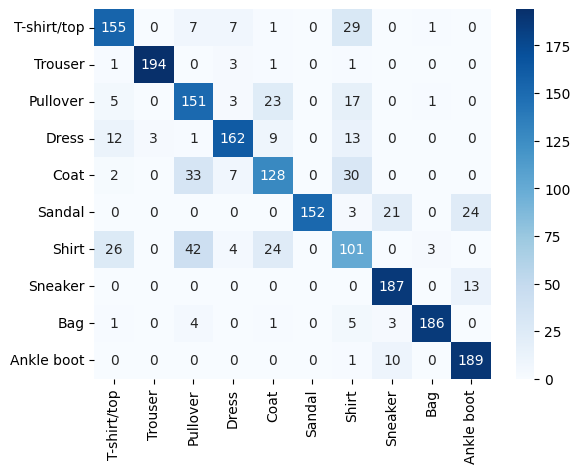

In [22]:
sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues',
xticklabels=class_names,
yticklabels=class_names
)

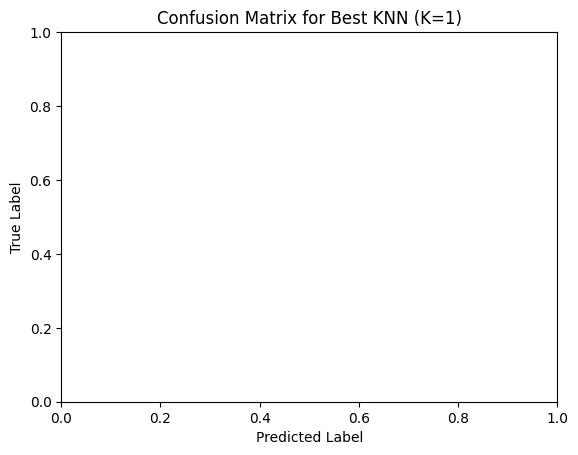

In [23]:
plt.title(
f'Confusion Matrix for Best KNN (K={best_k})'
)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()